             TRIP METRICS SUMMARY             
Calculated Distance:  5.979 km
Actual Map Distance:  6.200 km
Absolute Error:       0.221 km
Percentage Error:     3.56%


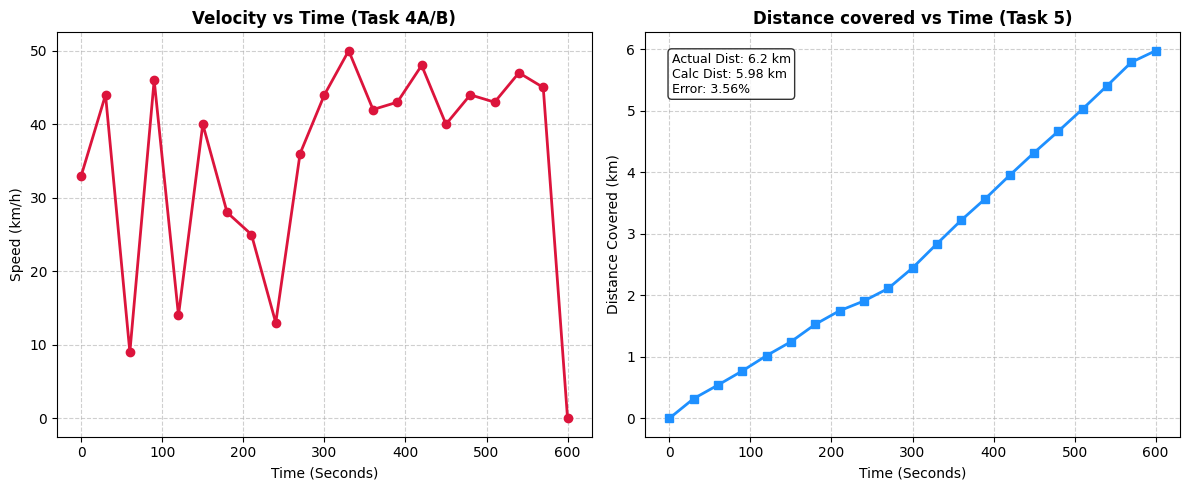

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Input the extracted data from your manual observations (Task 4A)
time = np.array([0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390, 420, 450, 480, 510, 540, 570, 600])
speed_kmh = np.array([33, 44, 9, 46, 14, 40, 28, 25, 13, 36, 44, 50, 42, 43, 48, 40, 44, 43, 47, 45, 0])

# --- CRITICAL VALUE: Update this with the real distance shown on your Google Maps screen record ---
actual_distance_km = 6.2  # Change this to your exact actual distance value

# 2. Convert speed measurements from km/h to m/s for kinematic integration
speed_ms = speed_kmh / 3.6

# 3. Calculate distance using Trapezoidal Numerical Integration
cumulative_distance_m = [0.0]
for i in range(1, len(time)):
    dt = time[i] - time[i-1]
    # Area of trapezoid: 0.5 * (v_start + v_end) * dt
    segment_distance = 0.5 * (speed_ms[i] + speed_ms[i-1]) * dt
    cumulative_distance_m.append(cumulative_distance_m[-1] + segment_distance)

# Convert arrays for calculation and plotting
cumulative_distance_km = np.array(cumulative_distance_m) / 1000.0
calculated_total_distance_km = cumulative_distance_km[-1]

# 4. Error Analysis Calculations (Task 5)
absolute_error_km = abs(calculated_total_distance_km - actual_distance_km)
percentage_error = (absolute_error_km / actual_distance_km) * 100

# Print reports to terminal
print("="*45)
print("             TRIP METRICS SUMMARY             ")
print("="*45)
print(f"Calculated Distance:  {calculated_total_distance_km:.3f} km")
print(f"Actual Map Distance:  {actual_distance_km:.3f} km")
print(f"Absolute Error:       {absolute_error_km:.3f} km")
print(f"Percentage Error:     {percentage_error:.2f}%")
print("="*45)

# 5. Generate and Save Visualizations (Task 6)
plt.figure(figsize=(12, 5))

# Plot A: Velocity vs. Time Graph
plt.subplot(1, 2, 1)
plt.plot(time, speed_kmh, marker='o', color='crimson', linestyle='-', linewidth=2)
plt.title('Velocity vs Time (Task 4A/B)', fontsize=12, fontweight='bold')
plt.xlabel('Time (Seconds)', fontsize=10)
plt.ylabel('Speed (km/h)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

# Plot B: Distance vs. Time Graph
plt.subplot(1, 2, 2)
plt.plot(time, cumulative_distance_km, marker='s', color='dodgerblue', linestyle='-', linewidth=2)
plt.title('Distance covered vs Time (Task 5)', fontsize=12, fontweight='bold')
plt.xlabel('Time (Seconds)', fontsize=10)
plt.ylabel('Distance Covered (km)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

# Overlay calculations inside chart space as context documentation
text_str = f'Actual Dist: {actual_distance_km} km\nCalc Dist: {calculated_total_distance_km:.2f} km\nError: {percentage_error:.2f}%'
plt.gca().text(0.05, 0.95, text_str, transform=plt.gca().transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('mobility_journey_analysis.png', dpi=300) # Saves directly to your folder directory
plt.show()
